<a href="https://colab.research.google.com/github/filippoiacchia-tech/BBS-Sleep-Quality-Prediction/blob/main/Sleep_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💤😴 Sleep Quality Prediction Model 🥱💤

 ## Filippo Iacchia, Alice Williams, Nourhene Ben Jeddou, Malcolm Palmer

##### In this project we created a neural network using a GRU architecture to predict sleep quality based on easily measurable lifestyle and health indicators.
##### We are using a synthetic dataset of 6 (fake) BBS students over the course of 117 days. The dataset has 15 features that will be explored in the following cells.
##### The goal is to be able to predict the sleep quality for the 8th night’s sleep based on the last 7 days.

# Import libraries

In [1]:
!pip install -q optuna kaleido gdown plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import optuna
import optuna.visualization as vis
import sklearn
import os
import gdown
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(42)
torch.manual_seed(42)

FILE_ID = '1LL6Lo6nDiVPYpAcCRzZSOH2eddOdd8dY'
url = f'https://drive.google.com/uc?id={FILE_ID}'
output = 'sleep_dataset.csv'

if not os.path.exists(output):
    print("Downloading dataset from Google Drive...")
    gdown.download(url, output, quiet=False)


df = pd.read_csv(output)
print(f"Dataset caricato con successo: {df.shape[0]} righe")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.3 MB/s eta 0:00:00


Downloading...
From: https://drive.google.com/uc?id=1LL6Lo6nDiVPYpAcCRzZSOH2eddOdd8dY
To: /content/sleep_dataset.csv
100%|██████████| 46.1k/46.1k [00:00<00:00, 48.1MB/s]

Dataset caricato con successo: 702 righe


# Loading data

In [2]:
df = pd.read_csv('sleep_dataset.csv')
print("Shape of df:", df.shape)
df.head(100)

Shape of df: (702, 18)


,user_id,sleep_score,day_index,is_weekend,bedtime_hour,wake_hour,sleep_duration_hours,bedtime_regularity_hours,caffeine_mg,last_caffeine_hour,alcohol_units_per_day,exercise_minutes,exercise_end_hour,screen_minutes_last_90,stress,is_sick,is_exam_week,is_holiday
0,1,0.7,0,0,23.4,8.6,9.2,0.2,70.4,11.7,0.4,28.3,20.4,30.4,2.7,0,0,0
1,1,0.9,1,0,22.5,7.6,9.1,0.4,64.4,11.0,0.6,21.7,15.4,29.7,2.2,0,0,0
2,1,0.8,2,0,22.9,8.8,9.8,0.4,40.4,9.7,0.4,12.8,17.3,22.9,2.4,0,0,0
3,1,0.7,3,0,23.1,7.9,8.9,0.3,77.8,16.7,2.5,17.5,17.4,53.7,2.2,0,0,0
4,1,0.8,4,0,22.9,7.9,9.0,0.3,78.4,12.3,0.5,18.2,15.8,27.6,2.8,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,0.7,95,0,22.6,7.3,8.7,0.3,172.4,14.1,0.0,38.7,20.2,13.4,3.5,0,0,0
96,1,0.8,96,1,22.9,7.9,9.0,0.2,116.7,10.4,0.7,19.3,18.7,59.9,2.0,0,0,0
97,1,0.8,97,1,22.5,8.0,9.5,0.3,94.6,14.5,0.4,29.4,20.7,2.5,1.0,0,1,0
98,1,0.8,98,0,22.4,7.8,9.4,0.3,93.5,11.9,0.0,47.2,17.0,19.9,2.2,0,1,0


# Defining target and features

In [3]:
y = df['sleep_score'].values.reshape(-1,1)  # target

df_features = df.drop(columns = ['user_id','day_index','sleep_score']) # remove user_id and day_index so we are just left with daily habit features

# Splitting features for different kinds of normalization

In [4]:
# features that will be fed into MinMaxScaler to be scaled from 0 to 1
minmax_features = [
'bedtime_hour',
'wake_hour',
'sleep_duration_hours',
'bedtime_regularity_hours',
'caffeine_mg',
'last_caffeine_hour',
'exercise_minutes',
'exercise_end_hour',
'screen_minutes_last_90'
]

# features that will be fed into StandardScaler to be centered around a mean of 0
standard_features = [
'alcohol_units_per_day',
'stress'
]

# features that are already either 0 or 1
binary_features = [
'is_weekend',
'is_sick',
'is_exam_week',
'is_holiday'
]

# Normalizing features to prepare for pytorch tensors

In [5]:
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(df_features[minmax_features]) # scale minmax_features to be between 0 and 1

std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(df_features[standard_features]) # standardize standard_features around a mean of 0

X_binary = df_features[binary_features].values # no scaling required, just convert to numpy array

# Combining normalized data with target

In [6]:
X_all = np.hstack([X_minmax, X_std, X_binary]) # horizontally stack all features

feature_names = minmax_features + standard_features + binary_features

df_scaled = pd.DataFrame(X_all, columns=feature_names) # convert combined scaled numpy array back into a pandas dataframe

df_scaled.insert(0, 'sleep_score', y) # add target back as first column df_scaled

print("Shape of df_scaled:", df_scaled.shape)
df_scaled.head(100)

Shape of df_scaled: (702, 16)


,sleep_score,bedtime_hour,wake_hour,sleep_duration_hours,bedtime_regularity_hours,caffeine_mg,last_caffeine_hour,exercise_minutes,exercise_end_hour,screen_minutes_last_90,alcohol_units_per_day,stress,is_weekend,is_sick,is_exam_week,is_holiday
0,0.7,0.975000,0.517544,0.814286,0.047619,0.133006,0.209790,0.226581,0.734694,0.161188,-0.398503,-0.174514,0.0,0.0,0.0,0.0
1,0.9,0.937500,0.429825,0.800000,0.142857,0.121670,0.160839,0.173739,0.224490,0.157476,-0.155031,-0.594352,0.0,0.0,0.0,0.0
2,0.8,0.954167,0.535088,0.900000,0.142857,0.076327,0.069930,0.102482,0.418367,0.121421,-0.398503,-0.426416,0.0,0.0,0.0,0.0
3,0.7,0.962500,0.456140,0.771429,0.095238,0.146987,0.559441,0.140112,0.428571,0.284730,2.157954,-0.594352,0.0,0.0,0.0,0.0
4,0.8,0.954167,0.456140,0.785714,0.095238,0.148120,0.251748,0.145717,0.265306,0.146341,-0.276767,-0.090546,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.7,0.941667,0.403509,0.742857,0.095238,0.325713,0.377622,0.309848,0.714286,0.071050,-0.885448,0.497227,0.0,0.0,0.0,0.0
96,0.8,0.954167,0.456140,0.785714,0.047619,0.220480,0.118881,0.154524,0.561224,0.317603,-0.033295,-0.762287,1.0,0.0,0.0,0.0
97,0.8,0.937500,0.464912,0.857143,0.095238,0.178727,0.405594,0.235388,0.765306,0.013256,-0.398503,-1.601962,1.0,0.0,1.0,0.0
98,0.8,0.933333,0.447368,0.842857,0.095238,0.176648,0.223776,0.377902,0.387755,0.105514,-0.885448,-0.594352,0.0,0.0,1.0,0.0


# Visualizing the time series decomposition: trend, seasonality, and noise

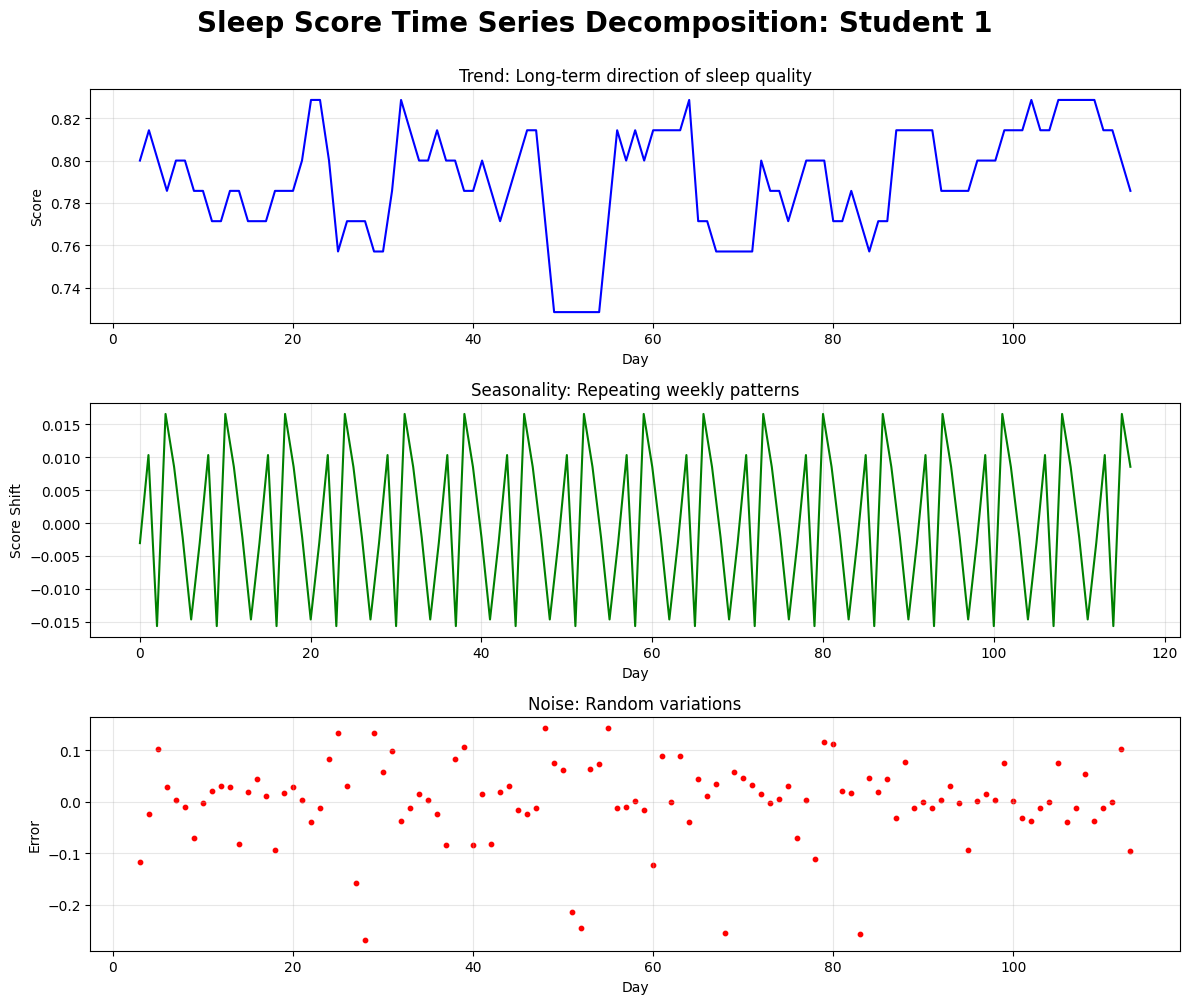

In [7]:
user_data = df[df['user_id'] == 1]['sleep_score'] # filter data for sleep_score column of student 1 to analyze their specific patterns
decomp = seasonal_decompose(user_data, model='additive', period=7) # decompose time series

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(decomp.trend, color='blue') ## graph of trend
axes[0].set_title('Trend: Long-term direction of sleep quality')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Day')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomp.seasonal, color='green') # graph of seasonality
axes[1].set_title('Seasonality: Repeating weekly patterns')
axes[1].set_ylabel('Score Shift')
axes[1].set_xlabel('Day')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(range(len(decomp.resid)), decomp.resid, color='red', s=10) # graph of noise
axes[2].set_title('Noise: Random variations')
axes[2].set_ylabel('Error')
axes[2].set_xlabel('Day')
axes[2].grid(True, alpha=0.3)

plt.suptitle("Sleep Score Time Series Decomposition: Student 1", y=1, fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Looping through each student's 117-day block

In [8]:
X = [] # will hold the "7-day history" blocks
y = [] # will hold the "8th-day sleep_score" targets

days_per_student = 117 # dataset contains 6 students, each with 117 days
window_size = 7

for i in range(6):
    start_row = i * days_per_student # grab the block of 117 days for this specific student
    end_row = (i + 1) * days_per_student
    student_data = df_scaled.iloc[start_row:end_row].values

    for j in range(len(student_data) - window_size): # slide a window over THIS student's data only
        X.append(student_data[j : j + window_size]) # input: 7 days of all features
        y.append(student_data[j + window_size, 0]) # target: the sleep_score of the very next day

X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (660, 7, 16)
Shape of y: (660,)


# Train/test split: train on first 5 students, test on 6th

In [9]:
train_size = 110 * 5 # each student has 110 windows (117 total days - 7 for the first window)
# use first 5 students for training (550 windows) and last student for testing (110 windows)

X_train = X[:train_size]
y_train = y[:train_size]
X_test = X[train_size:]
y_test = y[train_size:]

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (550, 7, 16)
Testing size: (110, 7, 16)


# Converting numpy arrays to pytorch tensors to perform backpropagation

In [10]:
X_train_t = torch.tensor(X_train).float() # convert to float tensors
y_train_t = torch.tensor(y_train).float()
X_test_t = torch.tensor(X_test).float()
y_test_t = torch.tensor(y_test).float()

y_train_t = y_train_t.view(-1, 1) # reshape y to be a column instead of a flat list
y_test_t = y_test_t.view(-1, 1)

print("X_train_t size:", X_train_t.shape) # output is: ([samples, days in window, habits])
print("y_train_t size:", y_train_t.shape) # output is: ([samples, target sleep score])

X_train_t size: torch.Size([550, 7, 16])
y_train_t size: torch.Size([550, 1])


# Defining the GRU architecture

In [11]:
class SleepGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(SleepGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True) # the GRU layer
        self.fc = nn.Linear(hidden_size, output_size) # converts GRU output to a single sleep score

    def forward(self, x):
        out, _ = self.gru(x) # forward propagate GRU
        out = self.fc(out[:, -1, :]) # output of the LAST day in the 7-day sequence
        return out

# Hyperparameter optimization through optuna


In [12]:
# to search for the best hyperparameters, we will use optuna instead of gridsearch.
# optuna uses a probabilistic approach, based on Bayes, in order to learn from trials.
# therefore, it focuses faster on the more promising areas of the search space, finding better hyperparameters,
# usually in less time than gridsearch and with less computational effort.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # check if a GPU (CUDA) is available to speed up training, otherwise, default to CPU
print("Active device:", device)

def objective(trial): # optuna objective function; 'suggests' values to test
    h_size = trial.suggest_categorical('hidden_size', [32, 64, 128, 256]) # GRU memory width
    n_layers = trial.suggest_int('num_layers', 1, 2) # stacked depth
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log = True) # learning rate (log scale for precision)

    model = SleepGRU(input_size = X_train_t.shape[2], hidden_size = h_size, num_layers = n_layers, output_size = 1).to(device) # initialize model and move it to active device
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    for epoch in range(30): # short training run to quickly evaluate quality of these parameters
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t) # ensure training data is on same device as the model
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

    return loss.item() # 'score' optuna uses to judge this trial

optuna.logging.set_verbosity(optuna.logging.WARNING) # stops red logging and only prints final results
study = optuna.create_study(direction = 'minimize') # create a study to 'minimize' loss function and run 25 different experiments
study.optimize(objective, n_trials = 25)

best_h = study.best_params['hidden_size']
best_n = study.best_params['num_layers']
best_lr = study.best_params['learning_rate']

print("")
print("Best configuration:") # parameters that achieved lowest loss
print("Hidden size:", best_h)
print("GRU layers:", best_n)
print("Learning Rate:", round(best_lr,5))

Active device: cpu

Best configuration:
Hidden size: 256
GRU layers: 2
Learning Rate: 0.00328


# Model training and backpropagation loop

In [13]:
model = SleepGRU(input_size = X_train_t.shape[2],
                 hidden_size = best_h,
                 num_layers = best_n,
                 output_size = 1).to(device) # re-initialize model with optuna's winning settings

criterion = nn.MSELoss() # MSE measures how far predictions are from the real scores
optimizer = torch.optim.Adam(model.parameters(), lr = best_lr)
epochs = 300
train_losses = []

print("Starting final training with Hidden:", best_h, "Layers:", best_n, "Learning Rate:", round(best_lr, 5))
for epoch in range(epochs):
    model.train() # set to training mode
    optimizer.zero_grad() # clear old gradients
    outputs = model(X_train_t.to(device)) # forward pass: make predictions for all 550 training windows
    loss = criterion(outputs, y_train_t.to(device)) # calculate how wrong the predictions were
    loss.backward() # backward pass: calculate how to change weights to reduce the loss
    optimizer.step() # optimization step: actually update the weights
    train_losses.append(loss.item()) # store the loss to check progress later

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {round(loss.item(), 4)}')

Starting final training with Hidden: 256 Layers: 2 Learning Rate: 0.00328
Epoch [50/300], Loss: 0.0111
Epoch [100/300], Loss: 0.0083
Epoch [150/300], Loss: 0.0062
Epoch [200/300], Loss: 0.0018
Epoch [250/300], Loss: 0.0003
Epoch [300/300], Loss: 0.0001


# Visualizing diagnostic performance

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




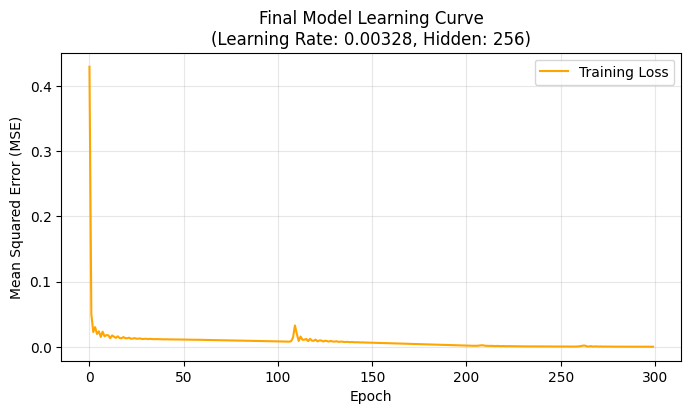

In [14]:
fig = vis.plot_param_importances(study) # hyperparameter importance
fig.show()

plt.figure(figsize = (8, 4)) # training performance
plt.plot(train_losses, label = 'Training Loss', color = 'orange')
plt.title(f'Final Model Learning Curve\n(Learning Rate: {best_lr:.5f}, Hidden: {best_h})')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

# Testing on unseen data (student 6)

In [15]:
model.eval() # set model to evaluation mode

with torch.no_grad(): # do not need to track gradients during testing
    test_predictions = model(X_test_t.to(device)) # get predictions for the test set

y_test_real = y_test_t.cpu().numpy().flatten()  # convert tensors back to numpy for plotting
y_test_pred = test_predictions.cpu().numpy().flatten()

# Predicted vs. observed sleep scores

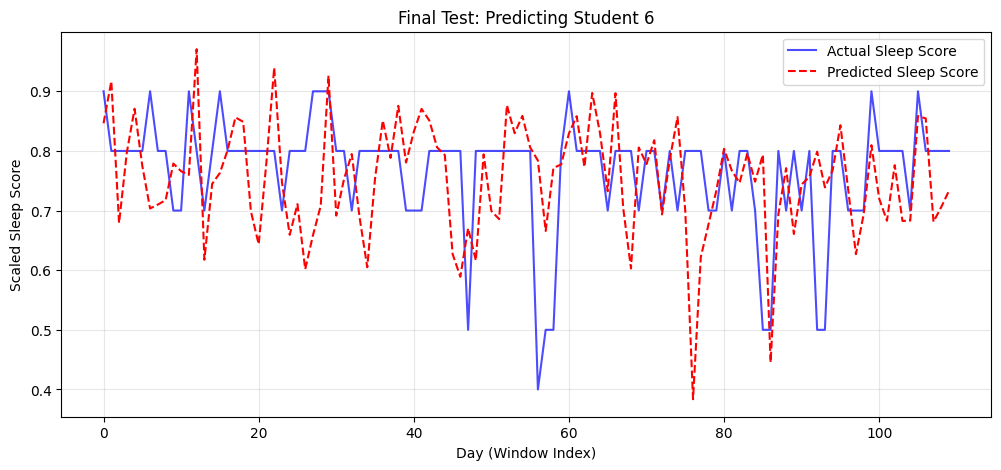

In [16]:
plt.figure(figsize = (12, 5))
plt.plot(y_test_real, label = 'Actual Sleep Score', color = 'blue', alpha = 0.7)
plt.plot(y_test_pred, label = 'Predicted Sleep Score', color = 'red', linestyle = '--')
plt.title('Final Test: Predicting Student 6')
plt.xlabel('Day (Window Index)')
plt.ylabel('Scaled Sleep Score')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

# Final summary

In [17]:
sample_input = X_test_t[-1:].to(device) # select a specific window from the test set
actual_8th_day = y_test_real[-1]

model.eval() # run the prediction
with torch.no_grad():
    prediction = model(sample_input).item()

mse = mean_squared_error(y_test_real, y_test_pred)
mae = mean_absolute_error(y_test_real, y_test_pred)
average_error_percent = mae * 100

print("Final Performance Metrics")
print("Mean Squared Error (MSE):", round(mse, 4))
print("Mean Absolute Error (MAE):", round(mae, 4))
print("---------------------------------")
print("On average, the model's prediction is within", round(average_error_percent, 2), "% of the actual sleep score.")
print("")
print("")
print("Live Model Inference")
print("Input: 7 Days of Sleep & Lifestyle History")
print("Task: Predict the 8th Day Sleep Score")
print("")
print("Model's Prediction for Day 8:", round(prediction,4))
print("Actual Recorded Score for Day 8:", round(actual_8th_day,4))
print("Prediction Variance (Error):", round(abs(prediction - actual_8th_day), 4))
print("------------------------------------")
print("Conclusion: Based on the patterns recognized over the last 7 days, the GRU model estimated a sleep quality of", round(prediction,2))


Final Performance Metrics
Mean Squared Error (MSE): 0.0151
Mean Absolute Error (MAE): 0.0943
---------------------------------
On average, the model's prediction is within 9.43 % of the actual sleep score.


Live Model Inference
Input: 7 Days of Sleep & Lifestyle History
Task: Predict the 8th Day Sleep Score

Model's Prediction for Day 8: 0.7333
Actual Recorded Score for Day 8: 0.8
Prediction Variance (Error): 0.0667
------------------------------------
Conclusion: Based on the patterns recognized over the last 7 days, the GRU model estimated a sleep quality of 0.73
